# PSY 39200 Introduction to Computational Psychology and AI

## Week 09 Hopfield Network

## There are 2 sets of questions and 3 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University


In [2]:
# @title Set Up Code

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Set a fixed seed value
SEED = 0

# Fix seed for NumPy (used in Hopfield network updates)
np.random.seed(SEED)


# Helper functions

def create_random_patterns(n_neurons, p):
    """
    Generate p random patterns of length n_neurons.
    Each entry is +1 or -1 with probability 1/2.
    """
    return [np.random.choice([+1, -1], size=n_neurons) for _ in range(p)]

def flip_bits(pattern, n_flip=5):
    """
    Create a noisy version of 'pattern' by flipping n_flip random bits.
    """
    noisy = pattern.copy()
    flip_indices = np.random.choice(range(len(pattern)), size=n_flip, replace=False)
    noisy[flip_indices] *= -1
    return noisy

def overlap(x, y):
    """
    Compute the overlap between two patterns (in {+1, -1}).
    Overlap = (1/N) * sum_i x_i * y_i
    Range is [-1, 1]. 1 means identical patterns, -1 means opposite.
    """
    return np.mean(x * y)

import numpy as np
import matplotlib.pyplot as plt



# Function to create 10x10 letter patterns
def generate_letter_patterns():
    letters = {
        "A": [
            "0011111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0000000000"
        ],
        "B": [
            "0111111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0111111000",
            "0000000000"
        ],
        "C": [
            "0011111000",
            "0100000100",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0100000100",
            "0011111000",
            "0000000000"
        ],
        "D": [
            "0111110000",
            "0100001000",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100000100",
            "0100001000",
            "0111110000",
            "0000000000"
        ],
        "E": [
            "0111111100",
            "0100000000",
            "0100000000",
            "0100000000",
            "0111111000",
            "0100000000",
            "0100000000",
            "0100000000",
            "0111111100",
            "0000000000"
        ]
    }

    patterns = []
    for letter, matrix in letters.items():
        binary_pattern = np.array([[1 if c == '1' else -1 for c in row] for row in matrix])
        binary_pattern = binary_pattern.astype(np.float32).flatten()  # Force float32
        patterns.append(binary_pattern)

    return patterns

# Function to display a pattern

def plot_pattern(pattern, title):
    plt.imshow(pattern.reshape(10, 10), cmap="gray_r")
    plt.title(title)
    plt.axis("off")
    plt.show()

def plot_three_patterns(original_pattern, noisy_pattern, recalled_pattern):
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))  # 1 row, 3 columns

    # Titles for each plot
    titles = ["Original Pattern", "Retrieval Cue", "Recalled Pattern"]
    patterns = [original_pattern, noisy_pattern, recalled_pattern]

    # Loop through the three plots
    for i, ax in enumerate(axes):
        ax.imshow(patterns[i].reshape(10, 10), cmap="gray_r")
        ax.set_title(titles[i])
        ax.axis("off")  # Remove axes for better visualization

    plt.tight_layout()  # Adjust layout to prevent overlapping
    plt.show()




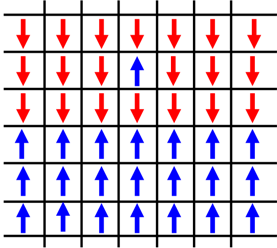

Source: https://www.bdhammel.com/ising-model/

# The Ising model

## 1. Historical Context and Motivation
The Ising model was introduced in the early 20th century by Wilhelm Lenz and his student Ernst Ising as a theoretical model to explain phase transitions—specifically the transition between magnetically ordered and disordered states in ferromagnets. Despite its origins in magnetism, the model’s applicability extends to a wide variety of systems exhibiting cooperative behavior, from neural networks to lattice gases.

---

## 2. What is a Spin?
In the context of the Ising model, a “spin” is a simplified representation of the magnetic moment of an atom or electron. While real magnetic moments in quantum mechanics are more complicated, the Ising model reduces each magnetic moment to one of two possible states, often labeled:

$$
s_i \in \{+1, -1\}.
$$

   - Each spin $s_i$ sits at a site $i$ in a lattice (which could be 1D, 2D, or higher-dimensional).  
   - “Up” spin (+1) can be interpreted as a microscopic magnetic dipole pointing up, and “down” spin (-1) as a dipole pointing down.
   - Unlike more general models (e.g., the Heisenberg or XY models) where spins can point in any direction on a sphere or circle, the Ising spin is restricted to two opposite orientations. This simplification often allows for exact or more tractable mathematical treatments while still capturing essential physical behaviors.

---

## 3. Interactions Between Spins
In a **ferromagnetic** Ising model, neighboring spins tend to align. Mathematically, this is captured by an interaction energy term:

$$
E_{\mathrm{int}} = -J \sum_{\langle i,j \rangle} s_i s_j,
$$

where:
- $\langle i,j \rangle$ indicates that $i$ and $j$ are neighboring lattice sites.
- $J$ is the coupling constant (positive $J$ for ferromagnetic interaction, negative $J$ for antiferromagnetic).

For $J > 0$ (ferromagnetic), the negative sign $-J$ indicates that the energy is minimized when spins are aligned—either all up or all down.

---

## 4. External Magnetic Field
Often, one also considers an external magnetic field $H$, which contributes an additional energy term:

$$
E_H = -h \sum_i s_i,
$$  

where $h$ is proportional to the external field $H$. This term favors spins aligned with the field direction.

---

## 5. Hamiltonian (Energy Function)
The total energy (Hamiltonian) of the Ising model is given by:

$$
H = -J \sum_{\langle i,j \rangle} S_i S_j - h \sum_i S_i
$$

where:
- $ H $ is the Hamiltonian (total energy of the system),
- $ J $ is the coupling constant (interaction strength) between neighboring spins,
  - If $ J > 0 $, the system favors **ferromagnetic** ordering (aligned spins).
  - If $ J < 0 $, the system favors **antiferromagnetic** ordering (alternating spins).
- $ S_i, S_j $ are the spin variables, taking values $ \pm1 $.
- $ \langle i,j \rangle $ denotes summation over nearest-neighbor spin pairs.
- $ h $ is the external magnetic field applied to the system.

---

## 6. Magnetization
**Magnetization** in this model is a measure of the net “alignment” of spins. Formally, the **total magnetization** $M$ is:

$$
M = \sum_i s_i.
$$

Often, one studies the **magnetization per spin**:

$$
m = \frac{1}{N} \sum_i s_i,
$$

where $N$ is the total number of spins.

- **Interpretation**:  
  - $m > 0$: more spins up than down.  
  - $m < 0$: more spins down than up.  
  - $m = 0$: disordered state (equal up and down on average).

- **Order Parameter**:  
  - In the context of phase transitions, $m$ is an **order parameter** capturing the system's degree of order.  
  - Above a critical temperature $T_c$ (for a ferromagnetic model), $m \approx 0$. Below $T_c$, spontaneous magnetization appears ($m \neq 0$).

---

## 7. Temperature and the Role of Statistics
In statistical mechanics, the probability of the system being in a given spin configuration depends on the **Boltzmann factor**:

$$
P(\{s_i\}) = \frac{e^{-\beta E(\{s_i\})}}{\sum_j e^{-\beta E(\{s_j\})}} \propto e^{-\beta E(\{s_i\})},
$$

where

- $ \beta = \frac{1}{k_B T} $ (with $k_B$ the Boltzmann constant and $T$ the absolute temperature),
- $ E(\{s_i\}) $ is the total energy of the spin configuration (including both the interaction and field terms).
- $\sum_j e^{-\beta E(\{s_j\})}$ is the total energy of all possible spin configurations

At higher temperatures, thermal fluctuations dominate, leading to more random orientations. At lower temperatures, spins are more likely to align due to interaction energy favoring ordered states.

---

## 8. Phase Transitions
A key reason the Ising model remains central in statistical physics is its ability to describe **phase transitions**:

1. **Spontaneous Symmetry Breaking**  
   - Below the critical temperature $T_c$, the system may “choose” a direction for magnetization (positive or negative) even if no external field is present.  
   - This means the symmetry between up/down spins is broken in the low-temperature phase.

2. **Critical Exponents and Universality**  
   - Near the critical point, thermodynamic quantities (e.g., heat capacity, susceptibility) often show power-law divergences.  
   - The Ising model is a prime example to study these universal features of second-order (continuous) phase transitions.

---

## 9. Ising models with different numbers of dimensions

**1D Ising model**: Spins are arranged in a line, interacting only with their two nearest neighbors.

**2D Ising model**: Spins are arranged on a square lattice, where each spin interacts with its four nearest neighbors.

**3D Ising model**: Spins are arranged on a cubic lattice, interacting with six nearest neighbors.

**4D Ising model**: Spins exist in a four-dimensional hypercubic lattice, where each spin interacts with eight nearest neighbors (each dimension adds two neighbors).


The Ising model extends naturally to higher dimensions because its definition relies only on local interactions within a lattice, and mathematically, a lattice can exist in any number of dimensions. While physical systems are typically 3D, higher-dimensional versions of the Ising model are useful in theoretical physics, quantum field theory, and computational simulations.


# How the Hopfield Network Was Inspired by the Ising Model

The **Hopfield network**, introduced by John Hopfield in 1982, can be viewed as a direct adaptation of concepts from the **Ising model** in statistical physics:

---

## 1. Energy Function Analogy
1. **Ising Model**  
   - Each spin $s_i \in \{+1, -1\}$ interacts with its neighbors via an energy function of the form  
     $$
       E = -\tfrac{1}{2}\sum_{i \neq j} J_{ij} s_i s_j - \sum_i h_i s_i,
     $$
     where $J_{ij}$ are symmetric coupling constants, and $h_i$ is an external field.

2. **Hopfield Network**  
   - Each neuron $x_i \in \{+1, -1\}$ is connected to others via weighted links $w_{ij}$ with a bias weight $\theta_i$. Hopfield introduced an **energy (Lyapunov) function** for the network:

     $$ E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j - \sum_{i} \theta_i s_i $$  

     where $w_{ij}$ corresponds to $J_{ij}$ and $\theta_i$ corresponds to $h_i$ in the Ising model.  

> **Key Point**: The network “settles” into states that locally minimize this energy—analogous to spins in the Ising model seeking low-energy configurations.

---

## 2. Binary States and Symmetric Weights

1. **Discrete Variables**  
   - In the Ising model, spins take two possible values $+1$ or $-1$.  
   - In the Hopfield network, neuron outputs are often taken to be $\pm 1$ or $\{0, 1\}$, mirroring the Ising spin states.

2. **Symmetry**  

   - For an Ising-like system to have a well-defined energy, the coupling matrix $\mathbf{J}$ is typically **symmetric** $J_{ij} = J_{ji}$.  

   - In the Hopfield network, the weight matrix $\mathbf{W}$ is also **symmetric**, ensuring the energy function is well-defined and decreases monotonically under asynchronous updates.

---

## 3. Stable States as Memories

1. **Spin Glass Perspective**  
   - In the **Ising spin glass**, stable (or metastable) states can represent different magnetization patterns or local minima.  
2. **Hopfield Interpretation**  
   - Stable states (local minima of the Hopfield energy) serve as **“stored memories”** or **“attractor states.”**  
   - When a partial or noisy input is presented, the network “relaxes” into the stored pattern closest (in energy) to that input, analogous to how an Ising system relaxes into a low-energy configuration.

---

## 4. Noise, Temperature, and Learning

1. **Thermal Fluctuations**  
   - In the Ising model, **temperature $T$** controls how spins flip randomly. At $T=0$, the system simply goes downhill in energy; at higher $T$, random fluctuations become significant.  

2. **Stochastic Hopfield Model** (not covered in this tutorial)  

   - One can introduce a **“temperature-like”** parameter to Hopfield networks (via probabilistic neuron updating) to explore dynamics similar to thermal fluctuations.  

   - This approach can help the network escape shallow local minima and find better global minima—paralleling **simulated annealing** in Ising systems.

3. **Learning Rules**  

   - Hopfield's **Hebbian learning** rule, $w_{ij} = \sum_\mu \xi_i^\mu \,\xi_j^\mu$ (where $\xi^\mu$ are training patterns), sets up weight configurations that encode certain memories.  

   - The underlying principle—linking local synaptic updates to pairwise correlations—is reminiscent of **pairwise interactions** in the Ising Hamiltonian.

---

## 5. Summary of Inspiration

- **Discrete States $\leftrightarrow$ Spin Variables**: Hopfield neurons mimic Ising spins, each taking values $\pm 1$ or $\{0, 1\}$.

- **Symmetric Weights $\leftrightarrow$ Spin Couplings**: The Ising coupling matrix becomes the Hopfield weight matrix.  

- **Energy (Lyapunov) Function $\leftrightarrow$ Ising Hamiltonian**: Both systems evolve to minimize an energy function with symmetric pairwise terms.  

- **Stable Configurations $\leftrightarrow$ Attractor States**: Just as spins converge to low-energy states, Hopfield networks converge to stored memory patterns.

**Therefore, Hopfield networks leveraged core ideas from the Ising model—binary states, pairwise symmetric couplings, and an energy minimization perspective—to formulate a model of associative memory.**


# Hopfield Network

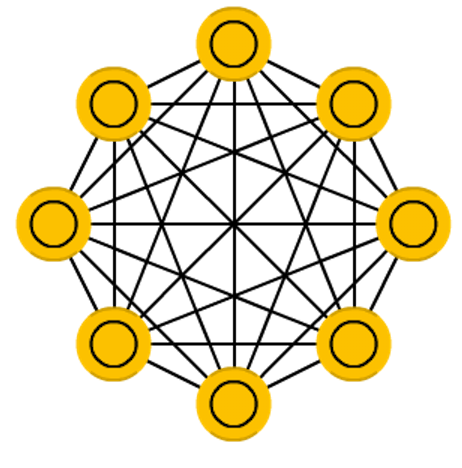

Source: https://primo.ai/index.php/Hopfield_Network_%28HN%29

## The assumptions of the Hopfield Network model

## 1. Binary Neuron States
- **Each neuron** $ x_i $ takes on one of two possible values, commonly $\pm 1$ or $\{0,1\}$.  
- This discretization mirrors the binary states of Ising spins in physics.

---

## 2. Symmetric Weights
- The **weight matrix** $ W $ is **symmetric**, meaning $ w_{ij} = w_{ji} $.  
- **Reason**: This symmetry ensures that an energy (Lyapunov) function can be defined which strictly decreases (or remains constant) under asynchronous neuron updates.  
- **No Directed Interactions**: Because $ w_{ij} = w_{ji} $, there is no sense of *direction* in the synaptic weights.

---

## 3. Zero Diagonal (No Self-Connections)
- Often, the diagonal elements $ w_{ii} $ (a neuron's “self-connection”) are **set to 0**.  
- **Reason**: A neuron is not assumed to directly feed back into itself in the model.

---

## 4. Asynchronous Update Rule

- **Hopfield updates** are typically performed **asynchronously** (one neuron at a time) in a random sequence. Each neuron's new state is chosen by a **sign function** of its local field.

- **Reason**: Under asynchronous updates, the network's energy function is guaranteed not to increase, hence the system moves steadily (or stays) at a local minimum.

---

## 5. Store Memory Patterns as Attractors

- The model **stores memory patterns** in its weight matrix using a **Hebbian** learning (or “training”) rule.

- **Assumption**: A **sparse** set of uncorrelated (or weakly correlated) patterns can be embedded such that each memory pattern is a local attractor.  

- **Consequence**: If the system is presented with a partial or noisy version of a stored pattern, it will evolve to the corresponding stable state (pattern completion or memory recall).

---

## 6. Deterministic
- **Deterministic Model**: Hopfield Network in this tutorial assumes neurons **deterministically** update via a sign function.  

---

These assumptions form the foundation of the classic Hopfield network framework. Variations relax or extend some of these (e.g., adding continuous units, introducing stochasticity, or modifying symmetry constraints), but the original Hopfield model rests on the points listed above.




## The activation state and the threshold of a neuron

The activation state of a neuron $i$ in Hopfield network is defined as $s_i$, and $s_i$ can only take one of the 2 possible values: {+1, -1}. A neuron $i$ is considered as "active" if $s_i = +1$ and it is considered as "inactive" if $s_i = -1$.

Note: It is also possible to let $s_i$ take one of the 2 possible values {1,0}. This setting is sometimes used when trying to model the biological neurons as being on ($s_i = 1$) or off ($s_i = 0$). However, it will make the math behind the model more complex, so we are not going to use this setting in the theory part of this tutorial.

The threshold of a neuron $i$ is $\theta_i$ and it determines how to update the activation state of the neuron $i$ using the following equation:

$$ s_i = sign \left( \sum_j w_{ij}s_j - \theta_i \right ) \tag{1} $$

Where $s_i$ and $s_j$ are the activation states of different neurons $i$ and $j$,

$w_{ij}$ is the connection weight between neuron $i$ and neuron $j$,

$\theta_i$ is the threshold of neuron $i$.

$s_i = +1$ if the right hand side of equation (1) is positive and $s_i = -1$ otherwise.

Alternatively, we can also express equation (1) in the matrix form:  

$$ \mathbf{s} = sign \left ( \mathbf{Ws} - \boldsymbol{\theta} \right )  \tag{2} $$



## The energy function

The energy function of a Hopfield network is defined as:

$$ E = -\frac{1}{2} \sum_{i,j} w_{ij} s_i s_j - \sum_{i} \theta_i s_i \tag{3}$$  

Where $s_i$ and $s_j$ are the activation states of two neurons $i$ and $j$,

$w_{ij}$ is the connection weight between neuron $i$ and neuron $j$,

$\theta_i$ is the threshold of neuron $i$.

Alternatively, we can also express equation (3) in the matrix form:  

$$ E = -\frac{1}{2} \mathbf{s}^T \mathbf{W} \mathbf{s} - \boldsymbol{\theta}^T \mathbf{s} \tag{4} $$

## How Hopfield Network stores memories (The learning rule)

Hopfield Network uses the **Hebbian learning rule** to store memories.

The **Hebbian learning rule** is based on the principle **"neurons that fire together wire together"**.

The learning rule for Hopfield network is given by:

$$
W_{ij} = \frac{1}{N} \sum_{\mu=1}^{P} \xi_i^\mu \xi_j^\mu , \quad W_{ii} = 0
$$

or

$$
W = \frac{1}{N} \sum_{\mu=1}^{P} \boldsymbol{\xi}^\mu \times \boldsymbol{\xi}^\mu, \quad W_{ii} = 0
$$

where:
- $ W_{ij} $ is the weight between neurons $ i $ and $ j $.
- $ N $ is the total number of neurons.
- $ P $ is the number of stored memory patterns.
- $ \xi_i^\mu $ is the value of neuron $ i $ in memory pattern $\boldsymbol{\xi}^\mu$.
- **Self-connections** are set to zero: $ W_{ii} = 0 $.

The bias term in the Hopfield network is given by:

$$
\theta_i = \frac{1}{N} \sum_{\mu=1}^P \xi_i^\mu
$$


The energy function defines a high dimensional energy landscape (an example in 1D is shown below). **The weights in the Hopfield network determine the shape of the energy landscape. The states of neurons in the network determines the location on the energy landscape.**

**The memories in the network correspond to the attractors (local minimum) on the energy landscape.** When we are storing memories in the network, we are changing the weights of the network so that the shape of the energy landscape would change. **In other words, when the network is trying to encode a memory, it is digging the energy landscape by changing connection weights to create attractors.**

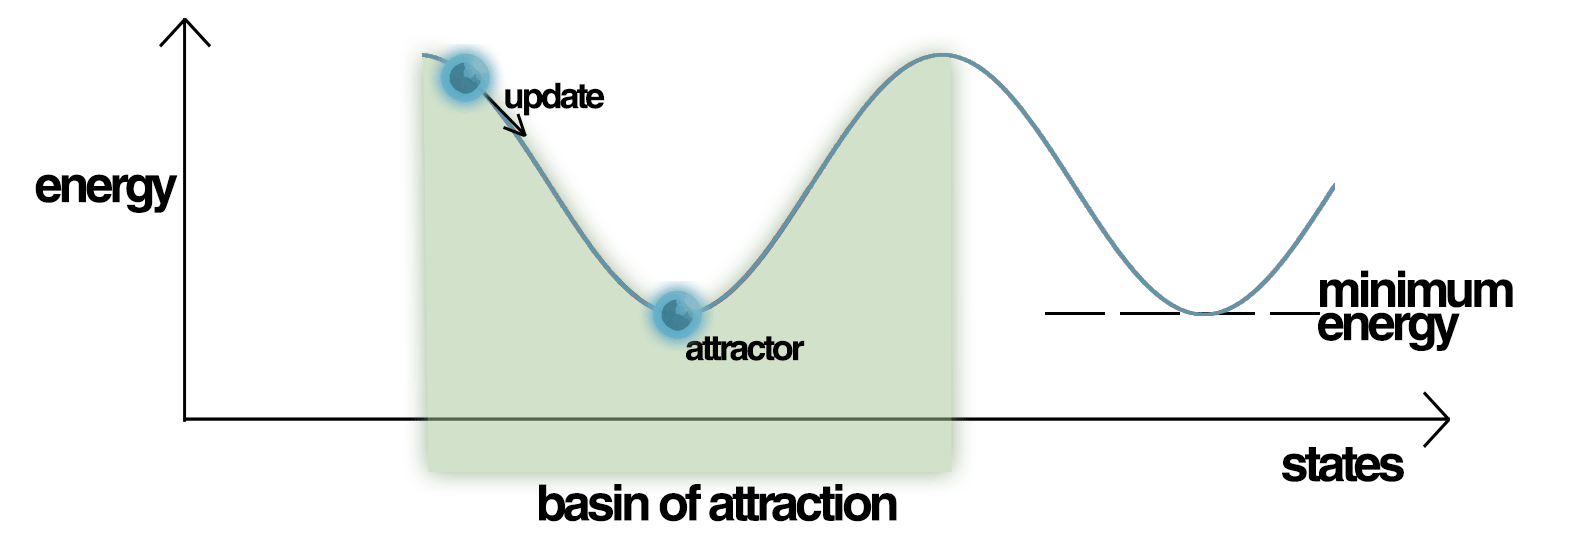

Source: https://en.wikipedia.org/wiki/Hopfield_network#/media/File:Energy_landscape.png

## The memory retrieval cue for a Hopfield Network

### **1. What is a Retrieval Cue?**
The **retrieval cue** for a Hopfield network is the **initial state of neurons** before the retrieval process begins. It serves as a **starting point** for the network to evolve toward a stored memory.

Let the stored patterns be:

$$
\boldsymbol{\xi}^\mu = (\xi_1^\mu, \xi_2^\mu, ..., \xi_N^\mu), \quad \mu = 1,2,\dots, P
$$

where:
- $ \xi_i^\mu \in \{ -1, +1 \} $ represents neuron states in the stored pattern $ \mu $.
- The network is designed to recall one of these patterns.

The **retrieval cue** is the **initial neuron state**:

$$
\boldsymbol{S}(0) = (S_1(0), S_2(0), ..., S_N(0))
$$

where $ S_i(0) $ is a **partially correct or noisy version** of a stored pattern $ \boldsymbol{\xi}^\mu $.

---

## **2. Types of Retrieval Cues**

### **(1) Perfect Memory Cue**
If the retrieval cue exactly matches a stored pattern:

$$
\boldsymbol{S}(0) = \boldsymbol{\xi}^\mu.
$$

- The network **immediately recognizes** the pattern.
- No updates are needed as the system is already at a stable attractor.

### **(2) Noisy or Incomplete Memory Cue**
A **corrupted cue** has some neurons flipped due to noise:

$$
S_i(0) = \xi_i^\mu \quad \text{for most } i, \quad \text{but some } S_i(0) \neq \xi_i^\mu.
$$

- The network must **correct these errors** iteratively.
- If the noise level is too high, the network may **fail to recall** the correct pattern.





## How Hopfield Network retrieves memories (Asynchronous State Updates)  

Starting from a memory retrieval cue, the Hopfield Network performs **asynchronous update** to the states of its neurons, only **one neuron $ s_i $** is updated at a time based on the following rule:

$$
s_i(t+1) = \text{sign} \left( \sum_{j} W_{ij} s_j(t) \right)
$$

where:
- $ s_i(t) $ is the state of neuron $ i $ at time $ t $.
- $ W_{ij} $ is the weight between neurons $ i $ and $ j $.
- The **sign function** is defined as:

  $$
  \text{sgn}(x) =
  \begin{cases}
  +1, & \text{if } x \geq 0 \\
  -1, & \text{if } x < 0
  \end{cases}
  $$

- The neurons are updated **one at a time**, chosen randomly or sequentially.


## Why successful memory retrieval is guaranteed (The property of the energy function and the convergence proof)

### **Properties of the Energy Function**
- $ E $ **always decreases or remains constant** as the network state is being updated.
- The network evolves toward a **stable state (local minimum of $ E $)**.

---

## **Convergence Proof**
The Hopfield network **converges** under the **asynchronous update rule**:  

The change in energy when updating neuron $ i $ is:

$$
\Delta E = E_{\text{new}} - E_{\text{old}}
$$

Using the energy function:

$$
E_{\text{old}} = -\frac{1}{2} \sum_{i,j} W_{ij} s_i s_j - \sum_i \theta_i s_i
$$

$$
E_{\text{new}} = -\frac{1}{2} \sum_{i,j} W_{ij} s_i' s_j - \sum_i \theta_i s_i'
$$

where $ s_i' $ is the updated state of neuron $ i $.

The difference is:

$$
\Delta E = -\sum_{i,j} [W_{ij} s_j (s_i' - s_i) + \theta_i (s_i' - s_i)] = -\sum_i \left[\sum_j (W_{ij}s_j + \theta_i)(s_i'-s_i) \right]
$$

⇒ $ \Delta E \leq 0 $

⇒ It always **decreases or keeps energy constant**

The minimum possible energy is **finite** because $ s_i $ can only take discrete values $ \pm1 $.

Since $ E $ decreases or stays the same in each update and is **bounded below**, the network must **converge to a stable state**.


### **Summary**
| **Concept** | **Explanation** |
|-------------|----------------|
| **Retrieval Cue** | Initial neuron states before retrieval begins. |
| **Perfect Cue** | Identical to a stored memory, no correction needed. |
| **Noisy or Incomplete Cue** | Some bits flipped, requiring iterative correction. |
| **Retrieval Process** | Iteratively updating neurons using weight matrix $ W $. |
| **Convergence** | Stops when neuron states stabilize at a memory attractor. |


# Question #1

$$
\Delta E = -\sum_{i,j} [W_{ij} s_j (s_i' - s_i) + \theta_i (s_i' - s_i)] = -\sum_i \left[\sum_j (W_{ij}s_j + \theta_i)(s_i'-s_i) \right]
$$

Can you explain why for a Hopfield Network with asynchronous state updates it is always true that $ \Delta E \leq 0 $?

Yes, because that with asynchronous updates, we update one neuron at a time, and that neuron is chosen to align with its local field. That makes the energy unable to increase.

## Implement a Hopfield Network

### Write a class for a Hopfield Network that can store and recall memories

# Coding Exercise #1 #2

In [3]:

np.random.seed(SEED)

class HopfieldNetwork:
    def __init__(self, n_neurons):
        """
        Initialize a Hopfield Network with n_neurons.
        Weights are stored in self.W (N x N), initialized to zero.
        """
        self.n_neurons = n_neurons
        self.W = np.zeros((n_neurons, n_neurons))

    def train_hebbian(self, patterns):
        """
        Train via classical Hebbian rule:
            W_ij = (1/N) * sum over mu [xi_i^mu * xi_j^mu]  (i != j)
        Diagonal weights set to zero.

        :param patterns: list (or array) of shape (p, N) with each pattern in {+1, -1}.
        """
        n_patterns = len(patterns)

        # Reset weights to zero each time before we train
        self.W = np.zeros((self.n_neurons, self.n_neurons))

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #1")
#############################################################################

        # Hebbian learning
        for p in patterns:
            # hint: np.outer()
            self.W += np.outer(p, p) / n_patterns

        # Remove self-connections & scale
        np.fill_diagonal(self.W, 0)
        self.W /= self.n_neurons

    def update_async(self, state, max_steps=100):
        """
        Asynchronous (random) updates of neurons until stable or max_steps reached.
        :param state: np.array of shape (N,) with entries in {+1, -1}.
        :param max_steps: how many total single-neuron updates to attempt.
        :return: final stable state.
        """
        state = state.copy()
        for _ in range(max_steps * self.n_neurons):
            i = np.random.randint(0, self.n_neurons)  # pick a random neuron

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #2")
#############################################################################

            # local field i.e. the inputs to neuron
            h_i  = np.dot(self.W[i], state)

            # Neuron update rule: x_i <- sign(h_i), tie-break with +1
            if h_i >= 0:
                state[i] = +1
            else:
                state[i] = -1
            # We could check for convergence by measuring changes,
            # but for simplicity, just run fixed steps or less.
        return state

    def recall(self, initial_state, max_steps=100):
        """
        Recall procedure: start from initial_state, apply asynchronous updates.
        """
        return self.update_async(initial_state, max_steps=max_steps)

### Use the Hopfield Network to store some memories

Create some memory patterns to be stored

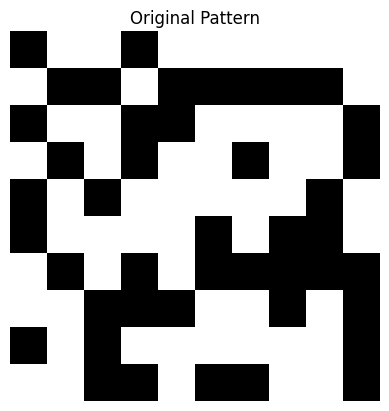

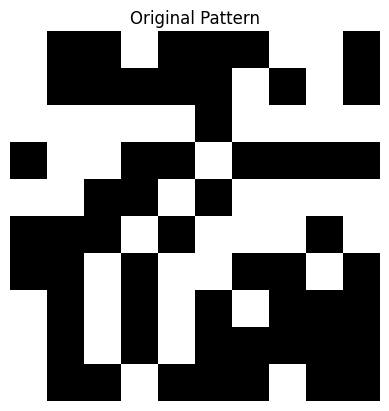

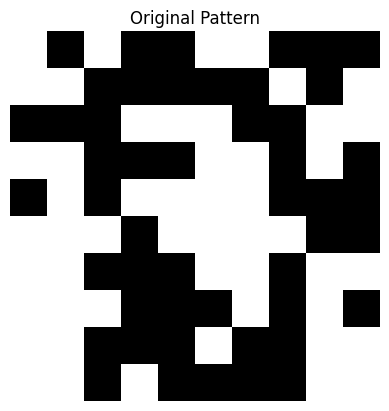

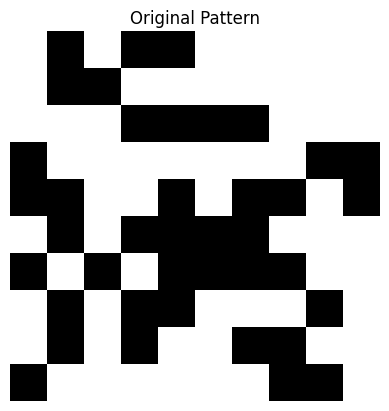

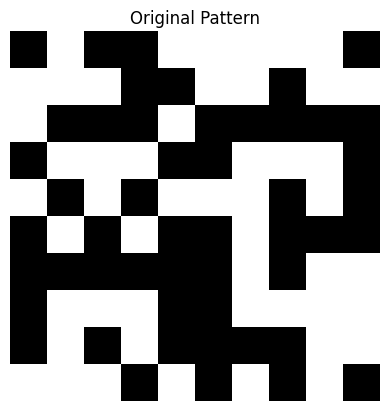

In [4]:

np.random.seed(SEED)

N = 100  # number of neurons
p_memory = 5 # number of memories to be stored

# Generate and display memory patterns
memory_patterns = create_random_patterns(100, p_memory)
for pattern in memory_patterns:
    plot_pattern(pattern, f"Original Pattern")



Train a Hopfield network to store these memory patterns

# Coding Exercise #3  

Single Pattern Recall


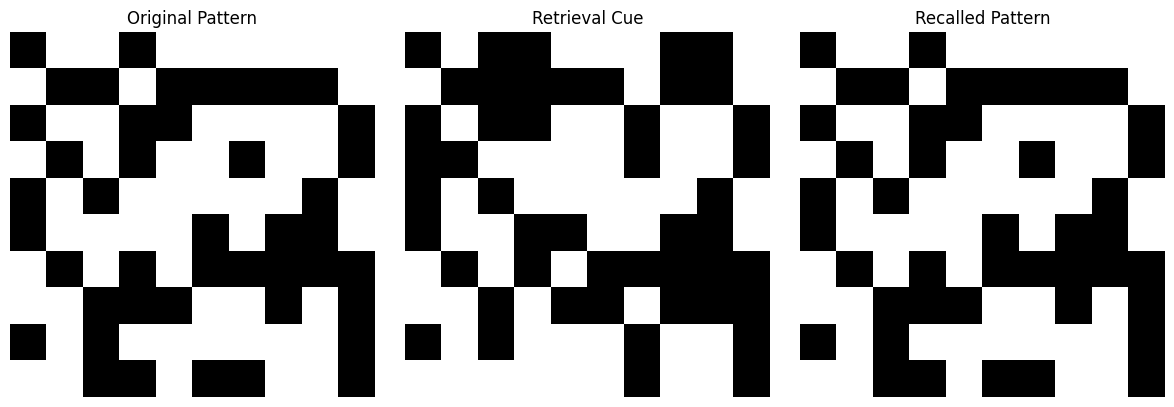

Overlap with original before recall: 0.6
Overlap with original after recall: 1.0



In [5]:

np.random.seed(SEED)

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #3")
#############################################################################

# Train a Hopfield network to store these memory patterns

N = 100

hop_net = HopfieldNetwork(N)

hop_net.train_hebbian(patterns=memory_patterns)

# Pick one pattern, flip some bits to convert it into a retrieval cue, and then recall

test_pattern_idx = 0

original_pattern = memory_patterns[test_pattern_idx]

noisy_pattern = flip_bits(original_pattern, n_flip=20)

recalled_pattern = hop_net.recall(original_pattern, max_steps=100)

print("Single Pattern Recall")

plot_three_patterns(original_pattern, noisy_pattern, recalled_pattern)

print("Overlap with original before recall:",
      overlap(noisy_pattern, original_pattern))
print("Overlap with original after recall:",
      overlap(recalled_pattern, original_pattern))
print()


## How many memories can be stored in a Hopfield Network (The capacity)  

A classical result in Hopfield networks is that one can store approximately
$$
p_{\max} \;\approx\; 0.15\,N
$$
patterns (where \(N\) is the number of neurons) before the network’s memory retrieval becomes unreliable. This fraction $\alpha_c \approx 0.15$ is referred to as the **capacity** of hopfield network.

Below is a sketch of how this capacity is estimated (Optional).

---

## 1. Hopfield Model

### 1.1. Neurons, Weights, and Stored Patterns
1. **Neurons**: $s_i \in \{+1, -1\}$, for $i = 1, \dots, N$

2. **Stored Patterns**: $\{\boldsymbol{\xi}^{\mu}\}$, with $\mu = 1, \dots, p$. Each $\boldsymbol{\xi}^{\mu}$ is a vector of length $N$, $\xi_i^{\mu} \in \{+1, -1\}$

3. **Hebbian Learning** (classic Hopfield rule):
   $$
     w_{ij} \;=\; \frac{1}{N} \sum_{\mu=1}^{p} \xi_i^{\mu} \, \xi_j^{\mu},
     \quad
     \text{for } i \neq j,\;\; w_{ii} = 0.
   $$

### 1.2. Overlap and Retrieval
- **Overlap** (or similarity) of the network state $\mathbf{s}$ with a stored pattern $\boldsymbol{\xi}^{\mu}$ is defined as
  $$
    m^\mu \;=\;\frac{1}{N} \sum_{i=1}^N s_i \,\xi_i^\mu.
  $$
- If $\mathbf{s}$ matches the pattern $\boldsymbol{\xi}^{\mu}$ perfectly, then $m^\mu = +1$.  
- The network is said to **retrieve** the $\mu$-th pattern if the final stable state after updates has a large (positive) overlap $m^\mu\approx 1$.

---

## 2. Idea of the Capacity Analysis

We want to know the **largest number of patterns** $p$ we can store such that each of those patterns remains a stable attractor of the Hopfield dynamics. Intuitively:
- As $p$ increases, the "crosstalk" among patterns also increases because each weight $w_{ij}$ is the sum over contributions from all patterns.  
- Beyond some critical $p$, the stored patterns may no longer be fixed points or might become unstable or very noisy attractors.

---

## 3. Local Field Calculation and Stability Condition

### 3.1. Local Field
For a given neuron $i$, the **local field** $h_i(\mathbf{s})$ (total inputs to neuron $i$) with the Hebbian weight rule is

$$
h_i(\mathbf{s})
\;=\;\sum_{j \neq i} w_{ij}\, s_j
\;=\;\frac{1}{N} \sum_{j \neq i}\sum_{\mu=1}^p \xi_i^{\mu}\,\xi_j^{\mu}\,s_j.
$$

Since $w_{ii}=0$, the term $j=i$ is omitted.

### 3.2. Considering Retrieval of a Specific Pattern
Assume we want the $\nu$-th pattern $\boldsymbol{\xi}^\nu$ to be a stable attractor. Then ideally, we set $\mathbf{s} = \boldsymbol{\xi}^\nu$.

Plugging $s_j = \xi_j^\nu$ into $h_i$, we get:

$$
h_i(\boldsymbol{\xi}^\nu)
\;=\;\frac{1}{N}\sum_{j \neq i}\sum_{\mu=1}^p \xi_i^{\mu}\,\xi_j^{\mu}\,\xi_j^{\nu}.
$$

We can split this double sum over $\mu$ into two parts:
1. The **$\mu = \nu$** term (the memory “signal”).  
2. The **$\mu \neq \nu$** terms (the “crosstalk noise” between different memories).

#### 3.2.1. Signal Term $\mu = \nu$
When $\mu=\nu$:

$$
\frac{1}{N}\sum_{j \neq i} \xi_i^{\nu}\,\xi_j^{\nu}\,\xi_j^{\nu}
\;=\;\frac{1}{N}\,\xi_i^{\nu}\sum_{j \neq i}\bigl(\xi_j^{\nu}\bigr)^2.
$$

Since $\xi_j^{\nu} \in \{\pm 1\}$, $(\xi_j^{\nu})^2 = 1$. For large $N$:

$$
\sum_{j \neq i} (\xi_j^{\nu})^2 = N-1 \;\approx\; N.
$$

Hence the signal term contributes approximately $\xi_i^{\nu}$.

#### 3.2.2. Noise Term $\mu \neq \nu$
For each $\mu \neq \nu$,

$$
\frac{1}{N}\sum_{j \neq i}\xi_i^{\mu}\,\xi_j^{\mu}\,\xi_j^{\nu}
\;\approx\;\frac{\xi_i^{\mu}}{N}\sum_{j=1}^N \xi_j^{\mu}\,\xi_j^{\nu}
$$

- If the patterns $\xi_j^\mu$ are **random** and **independent**, then $\sum_{j=1}^N \xi_j^{\mu}\,\xi_j^{\nu}$ behaves like a one-dimensional **random walk** in $\pm1$.  
- Its expected value is $0$, and its standard deviation scales like $\sqrt{N}$ (property of one-dimensional random walk).

Thus for large $N$, we can approximate each crosstalk term as a random variable of order $\sqrt{N}$, scaled by the factor $1/N$. Hence the crosstalk for each $\mu \neq \nu$ is of order $ \frac{\sqrt{N}}{N} = \frac{1}{\sqrt{N}}$

Since there are $(p-1)$ such crosstalk terms, the total crosstalk contribution is random walk with $(p-1)N$ steps and the standard deviation is roughly:

$$
\text{noise contribution} \;\sim\; \frac{\sqrt{(p-1)N}}{N} \xi_i^{\mu} \;\sim\; \sqrt{\frac{p}{N}} \xi_i^{\mu}
$$

---

## 4. Imposing the Stability Condition

For the Hopfield network to **correctly retrieve** pattern $\boldsymbol{\xi}^\nu$, we want each neuron $i$ to satisfy

$$
s_i \;=\; \xi_i^\nu
\quad\text{for correctly retrieving the memory and}\quad
\text{sign}\bigl[h_i(\boldsymbol{\xi}^\nu)\bigr] \;=\;\text{sign}(\xi_i^\nu) \text{  for stabilizing the memory}
$$

In other words, the local field at neuron $i$ (when the rest of the network is in state $\boldsymbol{\xi}^\nu$) must have the same sign as $\xi_i^\nu$. If this sign condition fails, that neuron may flip away from the pattern during updates.

### 4.1. Signal vs. Noise
- **Signal** $\approx \xi_i^\nu$  
- **Noise** $\sqrt{\frac{p}{N}} \xi_i^{\mu}$

For stability, we need $\bigl|\text{signal}\bigr|$ to exceed $\bigl|\text{noise}\bigr|$:

$$
\frac{\sqrt{N}}{\sqrt{p}} > 1
$$

or

$$
p \;<\; N
$$

Actually with a more accurate estimation

$$
p \;<\; \alpha_{c}\, N
$$

for some constant $\alpha_{c}$

To determine the value of $\alpha_{c}$, we assume the noise distribution is $N(0,\frac{p}{N})$

If we assume the correct signal should be +1, then for correct memory retrieval, we have

$$
signal + noise = \xi_i^\nu + N\left(0, \frac{p}{N} (\xi_i^{\mu})^2 \right) = 1 + N(0,p/N) \geq 0
$$

Therefore the noise term $N(0,p/N)$ must be greater than or equal to $-1$.

Then we analyze the **error probability** of retrieval for noise $N(0,p/N)$:

$$
P_{\text{error}} = \int_{-\infty}^{-1} \frac{1}{\sqrt{2\pi} \sigma} e^{-s^2 / (2 \sigma^2)} ds
$$

Where $\sigma^2 = p/N = \alpha_c$

Setting the **acceptable error probability** $P_{\text{error}} = 0.5\%$, numerical evaluation of this Gaussian integral yields:

$$
\alpha_c \approx 0.15
$$

Therefore, $p_{\max} \approx 0.15\, N$.






### Estimate the number of memories that can be stored in a Hopfield Network with simulations

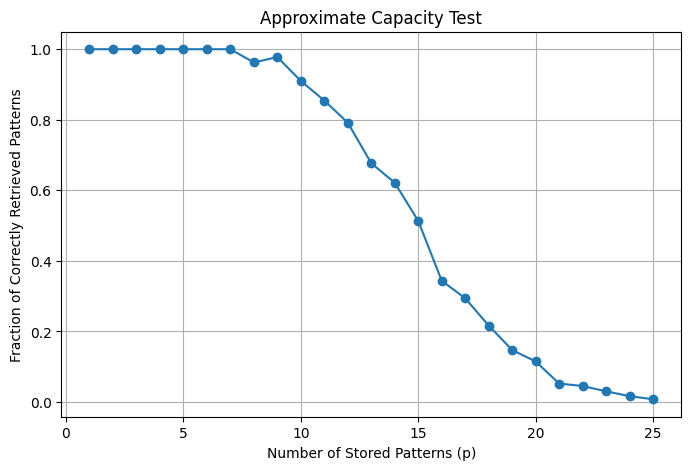

In [6]:

import numpy as np
import matplotlib.pyplot as plt

class HopfieldNetwork:
    def __init__(self, n_neurons):
        self.n_neurons = n_neurons
        self.W = np.zeros((n_neurons, n_neurons), dtype=float)

    def train_hebbian(self, patterns):
        """
        patterns: array of shape (p, N), entries in {-1, +1}
        """
        patterns = np.asarray(patterns, dtype=float)
        N = self.n_neurons

        # Vectorized Hebbian learning
        self.W = (patterns.T @ patterns) / N
        np.fill_diagonal(self.W, 0.0)

    def recall(self, state, max_steps=20):
        """
        Synchronous vectorized recall.
        Stops early if converged.
        """
        state = np.asarray(state, dtype=float).copy()

        for _ in range(max_steps):
            new_state = np.sign(self.W @ state)
            new_state[new_state == 0] = 1

            if np.array_equal(new_state, state):
                break
            state = new_state

        return state


def create_random_patterns(N, p):
    return np.where(np.random.rand(p, N) < 0.5, -1, 1)


def flip_bits_batch(patterns, n_flip):
    """
    Flip exactly n_flip bits in each pattern.
    patterns: shape (p, N)
    """
    patterns = patterns.copy()
    p, N = patterns.shape

    for i in range(p):
        flip_idx = np.random.choice(N, size=n_flip, replace=False)
        patterns[i, flip_idx] *= -1

    return patterns


# Estimate Hopfield capacity by fraction of perfectly retrieved patterns
N = 100
max_p = 25
num_trials = 10
max_steps = 20
n_flip = 20

fraction_correct_list = []
ps = range(1, max_p + 1)

for p in ps:
    n_correct = 0
    n_total = 0

    for _ in range(num_trials):
        patterns = create_random_patterns(N, p)

        hop_net = HopfieldNetwork(N)
        hop_net.train_hebbian(patterns)

        noisy_patterns = flip_bits_batch(patterns, n_flip=n_flip)

        for i in range(p):
            recalled = hop_net.recall(noisy_patterns[i], max_steps=max_steps)
            if np.array_equal(recalled, patterns[i]):
                n_correct += 1
            n_total += 1

    fraction_correct_list.append(n_correct / n_total)

plt.figure(figsize=(8, 5))
plt.plot(list(ps), fraction_correct_list, marker='o')
plt.title("Approximate Capacity Test")
plt.xlabel("Number of Stored Patterns (p)")
plt.ylabel("Fraction of Correctly Retrieved Patterns")
plt.grid(True)
plt.show()


## Spurious Memories Demo

First, Let us store 10 memory patterns into a Hopfield network and then try to recall the first memory pattern (memory #0).

In [7]:

np.random.seed(SEED)

# Spurious Memories
# We'll store a small set of patterns, then show an input that converges
# to a "spurious" attractor or combination.

N = 100
p_memories = 10
patterns_memories = create_random_patterns(N, p_memories)

# Train
hop_net = HopfieldNetwork(N)
hop_net.train_hebbian(patterns_memories)

original_pattern = patterns_memories[0]

noisy_pattern = flip_bits(original_pattern, n_flip=20)

recalled_memory = hop_net.recall(noisy_pattern, max_steps=100)

# See if recalled_memory is close to any original pattern
ovl = [overlap(recalled_memory, pat) for pat in patterns_memories]

print("Spurious Memories Demo")
print("Often, the system might converge to something that is not any stored pattern.")
print("Final overlap with each pattern:")
for i, pat in enumerate(patterns_memories):
    print(f"Pattern {i}: overlap = {overlap(recalled_memory, pat):.3f}")

Spurious Memories Demo
Often, the system might converge to something that is not any stored pattern.
Final overlap with each pattern:
Pattern 0: overlap = 1.000
Pattern 1: overlap = 0.080
Pattern 2: overlap = -0.140
Pattern 3: overlap = 0.120
Pattern 4: overlap = -0.040
Pattern 5: overlap = 0.000
Pattern 6: overlap = -0.040
Pattern 7: overlap = -0.040
Pattern 8: overlap = 0.020
Pattern 9: overlap = -0.060


Then, Let us store 25 memory patterns into a Hopfield network and then try to recall the first memory pattern (memory #0).

In [8]:

np.random.seed(SEED)

# Spurious Memories
# We'll store a small set of patterns, then show an input that converges
# to a "spurious" attractor

N = 100
p_memories = 25
patterns_memories = create_random_patterns(N, p_memories)

# Train
hop_net = HopfieldNetwork(N)
hop_net.train_hebbian(patterns_memories)

original_pattern = patterns_memories[0]

noisy_pattern = flip_bits(original_pattern, n_flip=20)

recalled_memory = hop_net.recall(noisy_pattern, max_steps=100)

# See if recalled_memory is close to any original pattern
ovl = [overlap(recalled_memory, pat) for pat in patterns_memories]

print("Spurious Memories Demo")
print("Often, the system might converge to something that is not any stored pattern.")
print("Final overlap with each pattern:")
for i, pat in enumerate(patterns_memories):
    print(f"Pattern {i}: overlap = {overlap(recalled_memory, pat):.3f}")

Spurious Memories Demo
Often, the system might converge to something that is not any stored pattern.
Final overlap with each pattern:
Pattern 0: overlap = 0.520
Pattern 1: overlap = 0.160
Pattern 2: overlap = -0.260
Pattern 3: overlap = 0.160
Pattern 4: overlap = -0.240
Pattern 5: overlap = -0.160
Pattern 6: overlap = -0.080
Pattern 7: overlap = 0.080
Pattern 8: overlap = 0.100
Pattern 9: overlap = -0.020
Pattern 10: overlap = -0.320
Pattern 11: overlap = -0.280
Pattern 12: overlap = -0.100
Pattern 13: overlap = -0.300
Pattern 14: overlap = 0.200
Pattern 15: overlap = -0.180
Pattern 16: overlap = -0.500
Pattern 17: overlap = 0.420
Pattern 18: overlap = -0.220
Pattern 19: overlap = 0.340
Pattern 20: overlap = 0.200
Pattern 21: overlap = -0.020
Pattern 22: overlap = -0.100
Pattern 23: overlap = 0.120
Pattern 24: overlap = 0.100


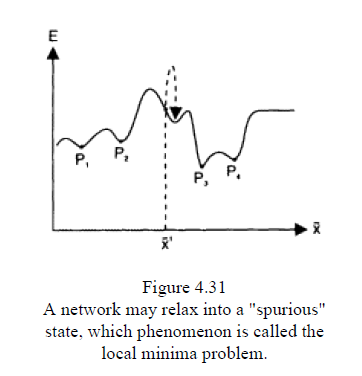

Source: https://skedbooks.com/books/neural-network-fuzzy-systems/limitations-to-using-the-hopfield-network/

When a Hopfield network stores too many memories, it may create spurious memoreis from the interactions between true memories.

A spurious memory is a "memory" that is not very similar to any of the stored memories. In biological brains, spurious memories could be hallucinations, false associations, or overfitted memories that reduce cognitive efficiency.

# Question #2

1. Did the network recall a spurious memory when 10 memories were stored in the network?

2. Did the network recall a spurious memory when 25 memories were stored in the network?

3. What problems would it cause when we are trying to store more memories that exceed the capacity of a Hopfield network ($0.15N$)?

1. No, the network did not recall a spurious memory. The final overlap with Pattern 0 is 1.000, which means it recovered the target memory exactly.
2. Yes, the network likely did recall a spurious memory. The overlap with Pattern 0 is only 0.520, and no pattern has overlap near 1.
3. It may create spurious memories from the interactions between true memories. The stored patterns start to interfere with each other, true memories become less stable, recall becomes unreliable, and extra unwanted attractors appear.

## Unlearning Spurious Memories through "Dreaming"

The term "dreaming" refers to a mechanism of noise-driven memory reprocessing, inspired by how sleep might refine memories in biological brains.

A typical approach is to repeating a process of memory recall and weakening spurious memory attractors by using a process in the opposite direction of Hebbian learning:

$$
     w_{ij} \;=\; w_{ij} - \frac{1}{N} \xi_i^{\mu} \, \xi_j^{\mu},
     \quad
     \text{for } i \neq j,\;\; w_{ii} = 0.
$$

Where $\xi^{\mu}$ is the spurious memory.

This is inspired by REM sleep, where the brain exhibits randomized activity that may help remove unnecessary memories while strengthening useful ones.